# 데모데이 프로젝트 — 스스로 배우는 셀프케어 코치

> 테마: **교육 & 학습** · LangGraph 교육 에이전트

## Step 1. 에이전트 설계

**이름**: 내 몸·마음 읽기 코치 (Self-Care Socratic Coach)

**목적 (어떤 문제를 해결하나)**
건강 정보는 넘치는데, 사람들은 "답"만 받고 **스스로 판단하는 힘은 안 길러져요.**
이 코치는 답을 대신 주지 않고, **소크라테스식 질문**으로 사용자가 자기 몸·마음 신호를
스스로 읽고 판단하는 법을 **"배우게"** 합니다. (물고기를 주지 않고 낚시를 가르치는 교육 에이전트)

**다루는 도메인 (4가지)**: 식단 · 수면 · 번아웃 · 운동 — `diagnose`가 오늘 입력의 맥락을 보고 알맞은 도메인을 고름.

**핵심 기능 (6가지)**
1. **맥락 진단(diagnose)** — 오늘 입력이 어느 도메인인지 판별(키워드→LLM 폴백), 안 배운 개념 선택 (진도 메모리 기반)
2. **소크라테스식 질문** — 답 대신 질문으로 스스로 생각하게 함
3. **반응형 힌트 루프** — 유저 답을 받아 유도, 못 맞히면 최대 2회 힌트 (조건 엣지 + 루프)
4. **정답 공개(reveal)** — 힌트 소진돼도 포기 않고 정답을 따뜻하게 알려주고 마무리 (가르치는 코치)
5. **웹검색 Tool** — 개념을 마스터하면 `@tool`+`ToolNode`로 실제 실천 팁을 웹에서 찾아 붙임 (강의 #14.1)
6. **안전 가드 + 진도 메모리** — 위험 신호 감지 시 전문가/1393 안내 · 배운 개념 기록해 다음엔 새 개념으로

> **LLM 적용**: `evaluate`·`empathy`·`hint`·`reveal`·`closing`·`enrich_agent`가 LLM(gpt-4o-mini).
> 나머지는 규칙기반이고, `OPENAI_API_KEY`가 없으면 규칙기반으로 자동 폴백 → 키 없이도 실행돼요.

**그래프 구조 (노드·엣지)** — `praise → enrich_agent ⇄ tools(웹검색) → closing`, 힌트 소진 시 `hint → reveal`

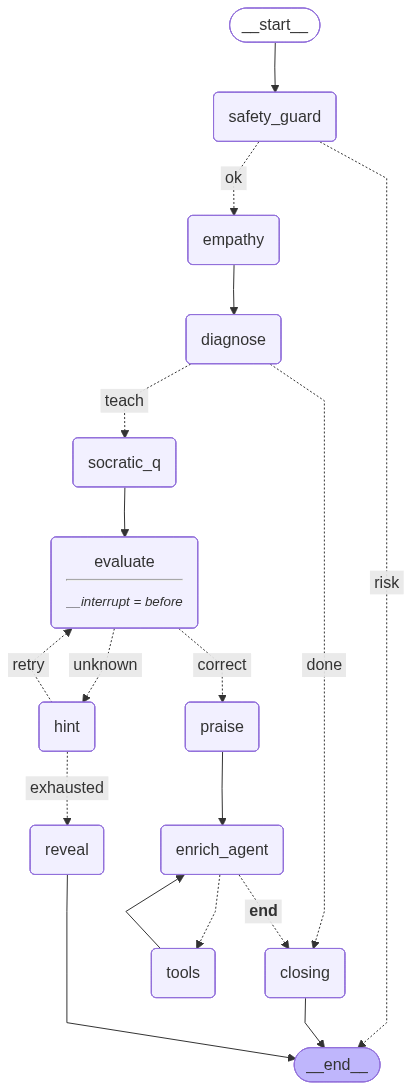

## Step 2. 기초 구축 (LangGraph)

아래 순서로 자족 실행됩니다: **State → 개념 데이터 → 노드(+Tool) → 그래프 조립 → 데모**.
각 셀은 원본 `.py`(state/concepts/nodes/graph)를 인라인한 것으로, 패키지 내부 import만 제거했습니다.

In [ ]:
# State — 그래프가 들고 다니는 공유 데이터 (커스텀 TypedDict)
"""그래프가 들고 다니는 상태 (그래프설계.md §1).

messages는 add_messages 리듀서로 대화를 누적하고, 나머지는 커스텀 TypedDict 필드.
"""
from typing import Annotated, TypedDict

from langgraph.graph.message import add_messages


class CoachState(TypedDict, total=False):
    # add_messages 리듀서: 노드가 return한 messages를 '덮어쓰기'가 아니라 '누적'.
    # ("ai", "텍스트") 튜플도 알아서 메시지 객체로 변환해준다.
    messages: Annotated[list, add_messages]
    today_input: str      # 이번 턴 사용자 입력 (예: "점심 라면+김밥")
    domain: str           # 오늘 입력이 어느 도메인인지 (식단/수면/번아웃/운동) — diagnose가 판별
    target_concept: str   # 이번에 가르칠 개념 key (concepts.py)
    learned: dict         # 진도 메모리 {concept_key: 숙련도} — 이미 앎/모름 판단
    hint_count: int       # 현재 개념 힌트 몇 번 줬나 (루프 종료용, max=HINT_MAX)
    user_answer: str      # 소크라테스 질문에 대한 유저 답
    verdict: str          # "correct" | "wrong" | "unknown"
    risk_flag: bool       # 의학 위험신호 감지 여부
    stage: str            # 현재 노드 (디버그·재개용)


HINT_MAX = 2  # 힌트 2번까지, 3번째도 못 맞히면 정답 알려주고 넘어감 (그래프설계.md §4)

In [ ]:
# 가르칠 개념 (식단·수면·번아웃·운동 4도메인) — 순수 데이터
"""가르칠 개념 (그래프설계.md §5). criteria.txt 근거.

순수 데이터 — LLM/LangGraph 무관. diagnose 노드가 오늘 입력의 domain을 판별해
그 도메인에서 안 배운 target_concept를 고르고, socratic_q/hint/evaluate가 이 내용을 쓴다.

domain: "식단" | "수면" | "번아웃" — diagnose가 입력 맥락에 맞는 개념만 고르게 하는 태그.
"""

CONCEPTS = {
    # ── 식단 ──────────────────────────────────────────────
    "protein_balance": {
        "domain": "식단",
        "title": "탄수에 단백질 곁들이기",
        "criteria": "단백질은 하루 체중 1kg당 약 1.2~1.6g (criteria.txt)",
        "socratic_q": "밥·면 같은 탄수 위주로 먹으면 몸에 뭐가 부족해지기 쉬울까요?",
        "hints": [
            "영양소 종류를 떠올려봐요. 탄수 말고요.",
            "단백질 쪽은 어때요? (계란·두부·고기 같은)",
        ],
        "answer_keywords": ["단백질", "protein", "계란", "두부", "고기", "닭", "생선"],
        "praise": "정확해요! 계란 하나만 얹어도 균형이 살아요.",
    },
    "veggie_fiber": {
        "domain": "식단",
        "title": "채소·식이섬유 챙기기",
        "criteria": "배달·외식·야식엔 채소가 부족하기 쉽다 (criteria.txt)",
        "socratic_q": "색깔로 보면 빠진 게 있지 않아요?",
        "hints": [
            "접시에 초록색이 보이나요?",
            "채소·식이섬유 쪽이에요. (나물·샐러드·김치)",
        ],
        "answer_keywords": ["채소", "야채", "식이섬유", "나물", "샐러드", "김치", "녹색"],
        "praise": "맞아요! 나물 한 가지만 곁들여도 든든해져요.",
    },
    "hydration": {
        "domain": "식단",
        "title": "수분 챙기기",
        "criteria": "짠 음식·음주는 수분을 뺏고 수면의 질을 떨어뜨린다 (criteria.txt)",
        "socratic_q": "음식 말고 같이 챙기면 좋은 게 있을까요?",
        "hints": [
            "짠 걸 먹었다면 더 필요한 거예요.",
            "물이에요. 한 컵 곁들이면 좋아요.",
        ],
        "answer_keywords": ["물", "수분", "water", "음료", "차"],
        "praise": "그렇죠! 물 한 컵이면 충분해요.",
    },
    # ── 수면 ──────────────────────────────────────────────
    "sleep_rhythm": {
        "domain": "수면",
        "title": "일정한 수면 리듬",
        "criteria": "취침·기상 시각이 들쭉날쭉하면 수면의 질이 떨어진다",
        "socratic_q": "수면의 질을 높이려면 자고 일어나는 시각을 어떻게 하면 좋을까요?",
        "hints": [
            "매일 같은 시각에 자고 일어나는지 떠올려봐요.",
            "핵심은 '규칙성'이에요. 주말에도 비슷하게요.",
        ],
        "answer_keywords": ["일정", "규칙", "같은 시간", "취침", "기상", "리듬"],
        "praise": "맞아요, 자고 일어나는 시각이 일정하면 수면의 질이 확 올라가요.",
    },
    "sleep_winddown": {
        "domain": "수면",
        "title": "잠들기 전 이완",
        "criteria": "자기 직전 화면·카페인은 잠드는 걸 방해한다",
        "socratic_q": "잠들기 직전에 뭘 하면 오히려 잠이 달아날까요?",
        "hints": [
            "손에 든 것과 저녁에 마신 걸 떠올려봐요.",
            "화면(폰)과 카페인이에요. 자기 전엔 줄이는 게 좋아요.",
        ],
        "answer_keywords": ["폰", "화면", "핸드폰", "카페인", "커피", "스마트폰", "불빛"],
        "praise": "그렇죠! 자기 전 화면·카페인만 줄여도 훨씬 잘 잠들어요.",
    },
    # ── 번아웃 ────────────────────────────────────────────
    "burnout_rest": {
        "domain": "번아웃",
        "title": "의식적인 회복 시간",
        "criteria": "지쳤을 땐 '아무것도 안 하는 쉼'을 일정에 넣어야 회복된다",
        "socratic_q": "번아웃에서 회복하려면 하루에 뭘 꼭 챙겨야 할까요?",
        "hints": [
            "쉬는 것도 '해야 할 일'처럼 정해둬야 해요.",
            "회복은 저절로 안 와요. 짧게라도 의식적으로 비우는 시간이 필요해요.",
        ],
        "answer_keywords": ["쉼", "휴식", "쉬는", "회복", "비우", "멈춤", "아무것도"],
        "praise": "맞아요, 짧게라도 의식적으로 쉬는 시간을 잡는 게 회복의 시작이에요.",
    },
    "burnout_boundary": {
        "domain": "번아웃",
        "title": "일과 삶의 경계",
        "criteria": "일이 삶으로 계속 넘어오면 소진된다 — 경계와 거절이 필요",
        "socratic_q": "일에 소진되지 않으려면 일과 쉼 사이에 뭐가 필요할까요?",
        "hints": [
            "퇴근 후에도 알림·연락을 붙잡고 있는지 떠올려봐요.",
            "핵심은 '경계'예요. 일과 쉼 사이에 선을 긋는 거요.",
        ],
        "answer_keywords": ["경계", "선", "거절", "퇴근", "끄", "알림", "구분"],
        "praise": "그렇죠! 일과 쉼 사이에 선을 그어야 소진되지 않아요.",
    },
    # ── 운동 ──────────────────────────────────────────────
    "exercise_consistency": {
        "domain": "운동",
        "title": "강도보다 꾸준함",
        "criteria": "가끔 몰아서 하는 고강도보다 자주 조금씩이 몸에 낫다",
        "socratic_q": "운동은 '한 번 세게'와 '자주 조금씩' 중 뭐가 몸엔 나을까요?",
        "hints": [
            "무리한 하루보다 이어지는 며칠을 떠올려봐요.",
            "핵심은 '꾸준함'이에요. 강도보다 빈도요.",
        ],
        "answer_keywords": ["꾸준", "자주", "규칙", "매일", "빈도", "습관"],
        "praise": "맞아요! 짧아도 자주 움직이는 게 가끔 몰아서보다 훨씬 나아요.",
    },
    "exercise_recovery": {
        "domain": "운동",
        "title": "쉬는 날도 운동의 일부",
        "criteria": "근육은 쉬는 동안 회복·성장한다 — 휴식일이 필요",
        "socratic_q": "매일 세게 하면 더 좋을까요, 쉬는 날도 필요할까요?",
        "hints": [
            "근육이 언제 자라는지 떠올려봐요. 운동할 때일까요?",
            "휴식일이에요. 쉬는 동안 회복·성장하거든요.",
        ],
        "answer_keywords": ["휴식", "쉬는 날", "회복", "쉬어", "쉼", "휴식일"],
        "praise": "그렇죠! 쉬는 날에 근육이 회복돼요. 휴식도 운동의 일부예요.",
    },
}

# diagnose가 안 배운 개념을 이 순서로 고른다 (같은 도메인 안에서의 우선순위)
CONCEPT_ORDER = [
    "protein_balance", "veggie_fiber", "hydration",     # 식단
    "sleep_rhythm", "sleep_winddown",                   # 수면
    "burnout_rest", "burnout_boundary",                 # 번아웃
    "exercise_consistency", "exercise_recovery",        # 운동
]

# diagnose가 오늘 입력의 domain을 빠르게 판별하는 키워드 (LLM 폴백 전에 먼저 본다)
DOMAIN_KEYWORDS = {
    "운동": ["운동", "헬스", "러닝", "달리", "걷", "산책", "근력", "유산소", "스쿼트", "요가", "홈트", "PT"],
    "수면": ["잠", "수면", "못 자", "못자", "잤", "불면", "새벽", "자다", "졸", "피곤", "뒤척", "눕"],
    "번아웃": ["번아웃", "지치", "소진", "무기력", "의욕", "탈진", "버겁", "쉬고 싶"],
    "식단": ["먹", "식사", "끼니", "점심", "저녁", "아침", "밥", "간식", "야식", "배달", "라면"],
}

In [ ]:
# 노드 + 웹검색 @tool + 맥락 분류 — LLM 노드는 키 없으면 규칙기반 폴백
"""그래프 노드 8개 (그래프설계.md §2).

각 노드 = state를 받아 바뀐 부분만 dict로 return 하는 함수.
지금은 **스텁** — LangGraph 강의 후 LLM 호출/판단 로직을 채운다.
(LLM 클라이언트는 llm.py로 분리 예정. 1주차는 규칙 기반으로 먼저 굴려보고 LLM은 그 다음.)
"""
import os

from dotenv import load_dotenv, find_dotenv


load_dotenv(find_dotenv(usecwd=True))  # OPENAI_API_KEY 로드 (cwd 기준, 노트북/스크립트 양쪽 안전)

# LLM (gpt-4o-mini). 키 없으면 None → 노드가 규칙기반으로 자동 폴백.
_llm = None
def get_llm():
    global _llm
    if _llm == "none":
        return None
    if _llm is None:
        if not os.getenv("OPENAI_API_KEY"):
            _llm = "none"; return None
        from langchain_openai import ChatOpenAI
        _llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.4)
    return _llm

# ── Tool 연동 (강의 #14.1 Tool Nodes 패턴) ──────────────────────────────
# @tool 로 정의 → get_llm_with_tools()가 bind_tools 로 LLM에 schema 알림 →
# graph.py의 ToolNode가 실제 실행. (여기선 실제 검색엔진으로 DuckDuckGo 무료·무키 사용)
from langchain_core.tools import tool


@tool
def search_web(query: str) -> str:
    """건강·식습관 개념을 일상에서 실천하는 실제 방법·팁을 웹에서 검색한다."""
    try:
        from langchain_community.tools import DuckDuckGoSearchRun
        return DuckDuckGoSearchRun().invoke(query)[:1500]
    except Exception as e:
        return f"(검색 실패: {e})"


TOOLS = [search_web]

# 툴 바인딩된 LLM (enrich_agent 전용). 키 없으면 None → enrich 스킵.
_llm_tools = None
def get_llm_with_tools():
    global _llm_tools
    if _llm_tools == "none":
        return None
    if _llm_tools is None:
        llm = get_llm()
        if llm is None:
            _llm_tools = "none"; return None
        _llm_tools = llm.bind_tools(TOOLS)   # LLM에 tool schema 알려주기 (강의 #14.1)
    return _llm_tools

# 위험신호 감지 (safety_guard) — 감지되면 코치 빠지고 전문가/1393.
# 단어 사이 '너무' 같은 게 껴도 잡히게 '앵커 + 증상' 동시등장으로 판정.
RISK_PAIRS = [
    ("가슴", ["아파", "아프", "통증", "조여", "쥐어", "짓눌"]),   # 심장 관련
    ("숨", ["안 쉬", "못 쉬", "막혀", "가빠", "차올", "쉬어지지"]),  # 호흡 곤란
]
RISK_SOLO = ["죽고 싶", "자해", "쓰러", "실신", "의식이 흐"]      # 단독으로도 위험


def is_risk(text):
    if any(k in text for k in RISK_SOLO):
        return True
    return any(anchor in text and any(v in text for v in verbs)
               for anchor, verbs in RISK_PAIRS)


def safety_guard(state):
    """위험신호 감지 → risk_flag. (그래프설계 §2-0)"""
    return {"risk_flag": is_risk(state.get("today_input", "")), "stage": "safety_guard"}


def empathy(state):
    """criteria 톤으로 먼저 공감 (번역체 금지). (§2-1) — LLM, 키 없으면 규칙기반 폴백."""
    ti = state.get("today_input", "")
    llm = get_llm()
    if llm is None:
        return {"messages": [("ai", "오늘도 기록 남겨줘서 좋아요. 같이 천천히 살펴봐요.")],
                "stage": "empathy"}
    try:
        msg = llm.invoke(
            f'너는 따뜻한 셀프케어 코치야. 사용자가 오늘 이렇게 기록했어: "{ti}"\n'
            "판단·평가·지시 없이, 자연스러운 한국어 **친근한 존댓말(~요체, 반말 금지)**로 "
            "딱 한 문장만 공감해줘. 번역체·이모지 금지."
        ).content.strip()
    except Exception:
        msg = "오늘도 기록 남겨줘서 좋아요. 같이 천천히 살펴봐요."
    return {"messages": [("ai", msg)], "stage": "empathy"}


def classify_domain(text):
    """오늘 입력이 어느 도메인인지 판별. 키워드 우선(빠름·확실) → LLM 폴백 → 기본 식단."""
    for dom, kws in DOMAIN_KEYWORDS.items():
        if any(k in text for k in kws):
            return dom
    llm = get_llm()
    if llm is not None:
        try:
            out = llm.invoke(
                f'다음 기록이 어느 주제인지 "식단/수면/번아웃/운동" 중 하나로만 답해: "{text}"'
            ).content.strip()
            for d in ("식단", "수면", "번아웃", "운동"):
                if d in out:
                    return d
        except Exception:
            pass
    return "식단"


def diagnose(state):
    """오늘 입력의 domain을 판별해, 그 도메인에서 안 배운 target_concept 선택. (§2-2)
    맥락 매칭: '못 잤어'→수면 개념, '치킨 먹음'→식단, '운동했어'→운동.
    해당 도메인을 다 배웠으면 남은 아무 개념으로 폴백, 그것도 없으면 None(→closing).
    """
    learned = state.get("learned", {})
    domain = classify_domain(state.get("today_input", ""))
    target = next((c for c in CONCEPT_ORDER
                   if c not in learned and CONCEPTS[c]["domain"] == domain), None)
    if target is None:                       # 그 도메인은 다 뗐으면 → 남은 아무 개념
        target = next((c for c in CONCEPT_ORDER if c not in learned), None)
    return {"target_concept": target, "domain": domain, "stage": "diagnose"}


def socratic_q(state):
    """답 대신 질문. (§2-3)"""
    c = CONCEPTS[state["target_concept"]]
    return {"messages": [("ai", c["socratic_q"])], "stage": "socratic_q"}


def evaluate(state):
    """유저 답 채점 → verdict. (§2-4) — LLM 의미 판정, 키 없으면 키워드 매칭 폴백.
    (LLM은 '프로틴 쉐이크' 같은 키워드에 없는 표현도 개념적으로 맞으면 정답 처리)
    """
    c = CONCEPTS[state["target_concept"]]
    ans = state.get("user_answer", "")
    if not ans.strip():
        return {"verdict": "unknown", "stage": "evaluate"}
    llm = get_llm()
    if llm is None:  # 규칙기반 폴백
        v = "correct" if any(k in ans for k in c["answer_keywords"]) else "wrong"
        return {"verdict": v, "stage": "evaluate"}
    prompt = (
        f"개념: {c['title']} — {c['criteria']}\n"
        f"이 개념에서 맞다고 볼 답의 방향(예): {', '.join(c['answer_keywords'])}\n"
        f'사용자 답: "{ans}"\n'
        "사용자 답이 이 개념을 개념적으로 맞게 짚었으면 correct, 틀렸으면 wrong, "
        "모르겠다는 취지면 unknown. 다른 말 없이 딱 한 단어로만 답해."
    )
    try:
        out = llm.invoke(prompt).content.strip().lower()
    except Exception:
        out = ""
    v = "correct" if "correct" in out else ("unknown" if "unknown" in out else "wrong")
    return {"verdict": v, "stage": "evaluate"}


def praise(state):
    """맞음 → 칭찬 + learned 기록. (§2-5a)"""
    key = state["target_concept"]
    learned = {**state.get("learned", {}), key: 1}
    return {
        "learned": learned,
        "messages": [("ai", CONCEPTS[key]["praise"])],
        "stage": "praise",
    }


def hint(state):
    """틀림/모름 → 힌트 1개 + hint_count++. (§2-5b) — LLM 반응형(유저 답을 받아 유도),
    키 없으면 concepts.py의 고정 힌트로 폴백.
    """
    n = state.get("hint_count", 0)
    c = CONCEPTS[state["target_concept"]]
    fallback = c["hints"][min(n, len(c["hints"]) - 1)]
    llm = get_llm()
    ans = state.get("user_answer", "").strip()
    if llm is None or not ans:
        return {"hint_count": n + 1, "messages": [("ai", fallback)], "stage": "hint"}
    try:
        msg = llm.invoke(
            f"너는 셀프케어 코치야. 사용자가 '{c['title']}' 개념을 스스로 깨닫게 유도하는 중이야.\n"
            f"개념 핵심: {c['criteria']}\n"
            f'사용자가 방금 이렇게 답했어: "{ans}"\n'
            "사용자 말을 먼저 한 마디로 받아준 뒤, 정답을 그대로 말하진 말고 개념 쪽으로 살짝 "
            "유도하는 질문 한 문장을 친근한 존댓말(~요체)로 해줘. 목록·이모지·번역체 금지, 한 문장.\n"
            f"(참고용 정석 힌트: {fallback})"
        ).content.strip()
    except Exception:
        msg = fallback
    return {"hint_count": n + 1, "messages": [("ai", msg)], "stage": "hint"}


def closing(state):
    """격려 + 다음에 스스로 해볼 것 1개. (§2-6) — LLM, 키 없으면 규칙기반 폴백."""
    learned = state.get("learned", {})
    llm = get_llm()
    if llm is None or not learned:
        if learned:
            last = CONCEPTS[list(learned)[-1]]["title"]
            msg = f"오늘 '{last}' 하나 스스로 찾아냈어요. 다음 끼니엔 뭐가 빠졌는지 먼저 떠올려봐요."
        else:
            msg = "오늘은 여기까지! 다음에 또 같이 살펴봐요."
        return {"messages": [("ai", msg)], "stage": "closing"}
    last = CONCEPTS[list(learned)[-1]]["title"]
    try:
        msg = llm.invoke(
            f"너는 셀프케어 코치야. 사용자가 오늘 '{last}' 개념을 스스로 깨쳤어. "
            "자연스러운 한국어 **친근한 존댓말(~요체, 반말 금지)**로, 칭찬 한 마디 + "
            "다음에 스스로 해볼 것 한 가지를 2문장으로. 번역체·이모지 금지."
        ).content.strip()
    except Exception:
        msg = f"오늘 '{last}' 하나 스스로 찾아냈어요. 다음 끼니엔 뭐가 빠졌는지 먼저 떠올려봐요."
    return {"messages": [("ai", msg)], "stage": "closing"}


# enrich_agent가 첫 진입 때 얹는 지시 (search_web 호출을 유도)
ENRICH_SYS = (
    "너는 셀프케어 코치야. 방금 사용자가 '{title}' 개념을 스스로 깨쳤어.\n"
    "이 개념을 일상에서 실천할 진짜 팁을 찾으려면 search_web 툴을 딱 한 번 써.\n"
    "검색 결과가 오면 그걸 바탕으로 친근한 존댓말 딱 한 문장으로 "
    "'더 알아보기 · ...' 형태의 실천 팁을 만들어줘. "
    "목록·번호·여러 문장 금지, 한 줄. 이모지·번역체 금지."
)


def enrich_agent(state):
    """마스터한 개념의 실천 팁을 웹 검색 Tool로 찾는 에이전트. (강의 #14.1 chatbot↔tools 루프)

    LLM이 tool call을 낼지 스스로 판단 → (graph의) ToolNode가 search_web 실행 →
    결과를 들고 이 노드로 복귀 → 더는 tool call이 없으면 tools_condition이 closing으로 보냄.
    키 없으면 조용히 스킵(규칙기반 흐름은 그대로 closing으로).
    """
    llm_t = get_llm_with_tools()
    learned = state.get("learned", {})
    if llm_t is None or not learned:
        return {"stage": "enrich"}
    title = CONCEPTS[list(learned)[-1]]["title"]
    msgs = list(state.get("messages", []))
    # 지시는 매 호출 끝에 얹는다(첫 호출=검색 유도, 둘째 호출=한 문장 팁 강제). state엔 안 남김.
    call_msgs = msgs + [("system", ENRICH_SYS.format(title=title))]
    resp = llm_t.invoke(call_msgs)      # bind_tools 된 LLM → tool call 또는 최종 답
    return {"messages": [resp], "stage": "enrich"}


def reveal(state):
    """힌트 소진 → 다그치지 않고 정답(개념)을 따뜻하게 알려주고 배운 걸로 기록. (§2-5c)
    설계 의도 "정답 알려주고 넘어감"의 실제 구현. 못 맞혀도 오늘 하나는 배우고 가게.
    """
    key = state["target_concept"]
    c = CONCEPTS[key]
    learned = {**state.get("learned", {}), key: 1}   # 다음엔 같은 개념 안 묻게
    llm = get_llm()
    if llm is None:
        msg = f"괜찮아요, 오늘은 제가 알려드릴게요 — 핵심은 '{c['title']}'예요. {c['criteria']} 다음엔 이걸 떠올려봐요."
    else:
        try:
            msg = llm.invoke(
                f"너는 셀프케어 코치야. 사용자가 '{c['title']}' 개념을 여러 번 못 맞혔어. "
                "이제 다그치지 말고, 괜찮다고 다독이며 따뜻하게 정답을 알려줘.\n"
                f"개념: {c['title']} — {c['criteria']}\n"
                "친근한 존댓말(~요체)로 핵심을 쉽게 풀어 2문장 이내. 이모지·번역체·목록 금지."
            ).content.strip()
        except Exception:
            msg = f"괜찮아요, 오늘은 제가 알려드릴게요 — 핵심은 '{c['title']}'예요. {c['criteria']}"
    return {"learned": learned, "messages": [("ai", msg)], "stage": "reveal"}


# hint 루프 탈출 조건 (그래프설계 §3)
def hint_exhausted(state):
    return state.get("hint_count", 0) >= HINT_MAX

In [ ]:
# 그래프 조립 — 조건분기·힌트루프·정답공개(reveal)·웹검색 툴 루프·interrupt_before
"""LangGraph 그래프 조립 (그래프설계.md §3).

흐름: safety_guard →(위험? END : empathy)→ diagnose →(다 앎? closing : socratic_q)
      → [유저 답 대기] → evaluate →(correct: praise / else: hint)
      hint →(힌트 소진? closing : socratic_q 루프)  → praise → closing → END

핵심 3가지:
- 분기: add_conditional_edges (앎/모름, 채점 결과, 힌트 소진)
- 유저 답 대기: evaluate 앞에서 멈춤 = compile(interrupt_before=["evaluate"]) + checkpointer
- 힌트 루프: hint → socratic_q 로 되돌아가는 엣지 (HINT_MAX 넘으면 탈출)
"""
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition   # 강의 #14.1 빌트인



def build_graph():
    b = StateGraph(CoachState)
    for fn in (safety_guard, empathy, diagnose, socratic_q,
               evaluate, praise, hint, reveal, closing, enrich_agent):
        b.add_node(fn.__name__, fn)
    b.add_node("tools", ToolNode(TOOLS))       # search_web 실행 노드 (강의 #14.1)

    b.add_edge(START, "safety_guard")
    b.add_conditional_edges("safety_guard",
        lambda s: "risk" if s.get("risk_flag") else "ok",
        {"risk": END, "ok": "empathy"})            # 위험신호면 코치 빠지고 종료
    b.add_edge("empathy", "diagnose")
    b.add_conditional_edges("diagnose",
        lambda s: "done" if s.get("target_concept") is None else "teach",
        {"done": "closing", "teach": "socratic_q"})  # 분기① 다 배웠나/가르칠 게 있나
    b.add_edge("socratic_q", "evaluate")           # 이 사이에서 유저 답 대기(interrupt_before)
    b.add_conditional_edges("evaluate",
        lambda s: s["verdict"],
        {"correct": "praise", "wrong": "hint", "unknown": "hint"})  # 분기② 채점
    b.add_conditional_edges("hint",
        lambda s: "exhausted" if hint_exhausted(s) else "retry",
        {"retry": "evaluate", "exhausted": "reveal"})  # 힌트 뒤 답 대기 / 소진되면 정답 공개
    b.add_edge("reveal", END)                            # 정답 알려주고 오늘은 마무리
    # 정답 → 칭찬 → enrich_agent가 웹 검색 Tool로 실천 팁 찾기 (강의 #14.1 chatbot↔tools 루프)
    b.add_edge("praise", "enrich_agent")
    b.add_conditional_edges("enrich_agent", tools_condition,
        {"tools": "tools", END: "closing"})    # tool call 있으면 tools, 없으면 closing (분기③)
    b.add_edge("tools", "enrich_agent")          # 검색 결과 들고 복귀
    b.add_edge("closing", END)

    # 유저 답을 기다리려면 evaluate 실행 직전에 멈춰야 함 → interrupt_before + checkpointer(재개용)
    return b.compile(checkpointer=MemorySaver(), interrupt_before=["evaluate"])


# ── 규칙기반 데모: LLM 없이 한 흐름 굴려보기 (라면+김밥 → 질문 → 답 → 힌트/칭찬) ──

In [ ]:
# ── 데모: 한 흐름 굴려보기 (공감→질문→오답 힌트→정답→웹검색 팁→마무리) ──
graph = build_graph()
cfg = {"configurable": {"thread_id": "demo"}}
seen = 0

def show():
    global seen
    for m in graph.get_state(cfg).values.get("messages", [])[seen:]:
        if getattr(m, "type", "") == "tool" or not str(getattr(m, "content", m)).strip():
            continue  # ToolNode 원본 검색 덤프·빈 tool-call 메시지는 숨김
        print("  \U0001FA7A", getattr(m, "content", m))
    seen = len(graph.get_state(cfg).values.get("messages", []))

print("[사용자] 점심에 라면이랑 김밥 먹었어")
graph.invoke({"today_input": "점심에 라면이랑 김밥 먹었어", "learned": {}, "hint_count": 0}, cfg); show()
for ans in ["글쎄 모르겠는데", "아 단백질?"]:
    print(f"[사용자] {ans}")
    graph.update_state(cfg, {"user_answer": ans}); graph.invoke(None, cfg); show()
print("\n[진도 메모리]", graph.get_state(cfg).values.get("learned"))

[사용자] 점심에 라면이랑 김밥 먹었어
  🩺 라면과 김밥 조합, 정말 맛있겠네요!
  🩺 밥·면 같은 탄수 위주로 먹으면 몸에 뭐가 부족해지기 쉬울까요?
[사용자] 글쎄 모르겠는데
  🩺 아, 그렇군요! 혹시 탄수화물 외에 다른 영양소 중에서 우리 몸에 중요한 역할을 하는 것들이 어떤 게 있을지 생각해보신 적 있으세요?
[사용자] 아 단백질?
  🩺 정확해요! 계란 하나만 얹어도 균형이 살아요.
  🩺 더 알아보기 · 운동 후 30분~1시간 내에 단백질과 적정량의 탄수화물을 함께 섭취하면 근육 회복에 효과적이에요.
  🩺 정말 대단하세요! 다음에는 탄수화물과 단백질을 조화롭게 섭취할 수 있는 식단을 계획해보시면 좋을 것 같아요.

[진도 메모리] {'protein_balance': 1}


## 결과

- `evaluate`(의미 판정)·`empathy`·`hint`·`reveal`·`closing`·`enrich_agent`는 **LLM(gpt-4o-mini)**, 나머지는 규칙기반(키 없으면 전부 폴백).
- 위 데모: 오늘 기록 → 공감 → 소크라테스 질문 → (오답) 반응형 힌트 → (정답) 칭찬 → **웹검색 Tool로 실천 팁** → 마무리.
- **Tool 연동**은 강의 #14.1 패턴 그대로: `@tool` → `bind_tools` → `ToolNode` → `tools_condition` 분기.
- 도메인(식단·수면·번아웃·운동)은 데이터라 그래프는 고정 — `diagnose`가 맥락으로 알맞은 개념을 고른다.